In [105]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [106]:
X,y = make_classification(n_features=5, n_informative=3, n_redundant=0 ,n_clusters_per_class=1, random_state=42)

In [107]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.203464,-1.606446,2.046468,0.129853,-2.421642,1
1,0.622850,-0.450065,0.067350,-1.010138,0.864347,0
2,-1.214189,-1.006017,-4.233589,-0.036573,-0.278435,0
3,0.232050,-0.471038,-2.628754,-0.374400,-0.557873,0
4,0.074095,1.502357,1.388774,0.847465,-0.804174,1


In [108]:
# function for row sampling
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]), replace = True)

In [109]:
# function for feature sampling

def sample_features(df,percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1])))
    return df[cols]

In [110]:
# function for combined sampling
def combined_sampling(df,row_percent,col_percent):
    new_df = sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)
    

In [111]:
df1 = sample_rows(df,0.2)

In [112]:
df2 = sample_rows(df,0.2)

In [113]:
df3 = sample_rows(df,0.2)

In [114]:
df1.shape, df2.shape, df3.shape

((20, 6), (20, 6), (20, 6))

In [115]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [116]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [117]:
from sklearn.tree import plot_tree

[Text(0.6, 0.875, 'x[3] <= -0.212\ngini = 0.375\nsamples = 20\nvalue = [15, 5]'),
 Text(0.4, 0.625, 'x[2] <= 0.378\ngini = 0.208\nsamples = 17\nvalue = [15, 2]'),
 Text(0.5, 0.75, 'True  '),
 Text(0.2, 0.375, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.6, 0.375, 'x[0] <= -0.38\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.625, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.7, 0.75, '  False')]

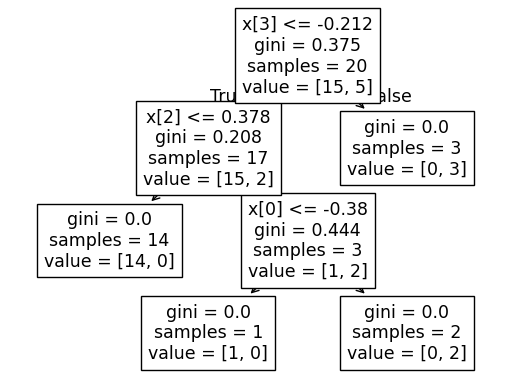

In [118]:
plot_tree(clf1)

[Text(0.4, 0.875, 'x[2] <= -0.254\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[2] <= 0.233\ngini = 0.165\nsamples = 11\nvalue = [1, 10]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[3] <= -1.409\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]')]

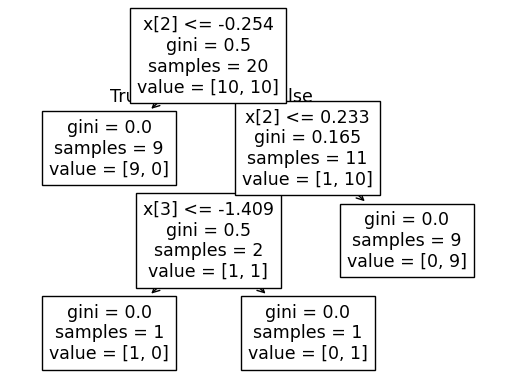

In [119]:
plot_tree(clf2)

[Text(0.6, 0.8333333333333334, 'x[3] <= -0.358\ngini = 0.48\nsamples = 20\nvalue = [12, 8]'),
 Text(0.4, 0.5, 'x[2] <= 1.368\ngini = 0.245\nsamples = 14\nvalue = [12, 2]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.7, 0.6666666666666667, '  False')]

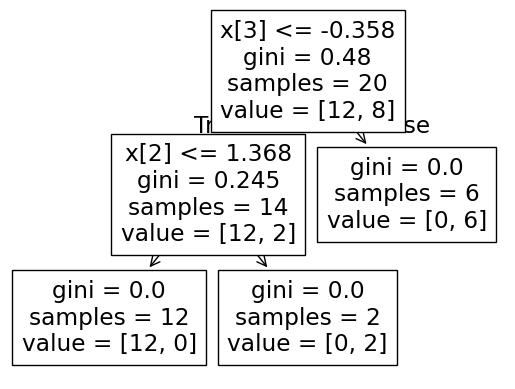

In [120]:
plot_tree(clf3)

In [121]:
clf1.predict(np.array([0.203464,-1.606446,2.046468,0.129853,-2.421642]).reshape(1,5))

/Users/pratyushtiwari/Desktop/Machine Learning CampusX/myvenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [122]:
clf2.predict(np.array([0.203464,-1.606446,2.046468,0.129853,-2.421642]).reshape(1,5))

/Users/pratyushtiwari/Desktop/Machine Learning CampusX/myvenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [123]:
clf3.predict(np.array([0.203464,-1.606446,2.046468,0.129853,-2.421642]).reshape(1,5))

/Users/pratyushtiwari/Desktop/Machine Learning CampusX/myvenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [124]:
import random
sample_features(df,0.5)  

,col1,col4,col2
0,0.203464,0.129853,-1.606446
1,0.622850,-1.010138,-0.450065
2,-1.214189,-0.036573,-1.006017
3,0.232050,-0.374400,-0.471038
4,0.074095,0.847465,1.502357
...,...,...,...
95,0.035264,-1.147069,1.964725
96,0.628346,-1.187769,0.624120
97,1.831459,-0.875682,-1.320233
98,-0.220970,-0.269342,-0.112328


In [125]:
df_c_1 = sample_features(df,0.8)

In [126]:
df_c_2 = sample_features(df,0.8)

In [127]:
df_c_3 = sample_features(df,0.8)

In [128]:
df_c_3.shape

(100, 4)

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.053909,-3.861208,1.530963,0.596692,1.030284,0
1,3.243492,1.666651,3.179016,-0.825861,0.778528,1
2,0.712446,-1.201617,1.528624,-0.422788,-0.376825,0
3,1.388329,1.538995,1.243716,0.740905,-2.081063,1
4,2.394647,-3.576345,0.914217,0.363136,2.110329,0
